# Introduction to Reinforcement Learning — Live Demo (Part 1)
### GridWorld Q-learning + LunarLander PPO

This notebook is built for a **live talk demo**. Run cells top to bottom.

- **Part A — GridWorld (Q-learning):** trains in seconds, so you can watch the policy
  (the arrows) improve episode by episode. Good for teaching the vocabulary:
  *agent, environment, state, action, reward, policy.*
- **Part B — LunarLander (PPO):** a more visually fun environment. We record a
  **random agent** first (it flails), then either train live for a few minutes or
  load a **pretrained checkpoint** for a guaranteed "wow" moment.

All checkpoints are saved to `checkpoints/` so you (or the audience) can reload them later.

> Runtime tip: for Part B, use a GPU runtime (Runtime → Change runtime type → T4 GPU) —
> training is much faster, though it will still run on CPU.


In [2]:
import os
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("checkpoints/gridworld", exist_ok=True)
os.makedirs("checkpoints/lunarlander", exist_ok=True)
print("checkpoints/ folder ready")


checkpoints/ folder ready


## Part A — GridWorld with tabular Q-learning

A tiny 6x6 grid: the agent starts top-left, must reach the goal `G` bottom-right,
and avoid pit cells `X` (instant, big negative reward). This is the simplest possible
setting to show the core RL loop updating **live**.


## Part A — GridWorld with tabular Q-learning

A tiny 6x6 grid: the agent 🦄 starts top-left, must reach the coin 💰 bottom-right,
and avoid octopus 🐙 pit cells (instant, big negative reward). This is the simplest
possible setting to show the core RL loop updating **live** — and made a bit more fun
to look at than plain arrows on a page.


In [3]:
import numpy as np
import random

class GridWorld:
    """A minimal grid environment for teaching the RL loop."""

    ACTIONS = {0: "up", 1: "down", 2: "left", 3: "right"}

    def __init__(self, size=6, pits=None, goal=None):
        self.size = size
        self.start = (0, 0)
        self.goal = goal or (size - 1, size - 1)
        self.pits = pits or [(2, 2), (3, 1), (1, 4)]
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        r, c = self.state
        if action == 0:      # up
            r = max(0, r - 1)
        elif action == 1:    # down
            r = min(self.size - 1, r + 1)
        elif action == 2:    # left
            c = max(0, c - 1)
        elif action == 3:    # right
            c = min(self.size - 1, c + 1)
        self.state = (r, c)

        if self.state == self.goal:
            return self.state, 10.0, True
        elif self.state in self.pits:
            return self.state, -10.0, True
        else:
            return self.state, -0.1, False   # small step cost encourages efficiency


env = GridWorld(size=6)
print("Environment created. Goal:", env.goal, "| Pits:", env.pits)


Environment created. Goal: (5, 5) | Pits: [(2, 2), (3, 1), (1, 4)]


### Graphics setup: unicorn agent, octopus pits, coin goal

`matplotlib`'s text renderer generally **cannot draw color emoji glyphs** — it silently
draws nothing, regardless of font size, so asking it to render 🦄 as text just gives a
blank space. Instead we render each emoji once as a small image with **Pillow** (which
does support color emoji) and place that image on the plot. There's still a **fallback**
to plain colored shapes (star / dark circle / gold circle) if no emoji font can be found
at all — check the smoke test output below.


In [4]:
# --- Locate a color emoji font (no hardcoded user path) and install one if on Colab ---
import sys, os, subprocess

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

if IN_COLAB:
    # Colab is Debian/Ubuntu-based, so Noto Color Emoji can be apt-installed.
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-noto-color-emoji"],
                    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(["fc-cache", "-f"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

_EMOJI_FONT_CANDIDATES = [
    "/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf",                    # Linux / Colab
    "/System/Library/Fonts/Apple Color Emoji.ttc",                          # macOS (built-in, no install needed)
    os.path.expanduser("~/Library/Fonts/NotoColorEmoji-Regular.ttf"),       # macOS, if installed via Homebrew
    os.path.expanduser("~/Library/Fonts/NotoColorEmoji.ttf"),
    "C:\\Windows\\Fonts\\seguiemj.ttf",                                    # Windows (Segoe UI Emoji)
]

_EMOJI_FONT_PATH = next((p for p in _EMOJI_FONT_CANDIDATES if os.path.exists(p)), None)
print("Emoji font found:", _EMOJI_FONT_PATH or "none - will use shape fallback")


Running in Colab: False
Emoji font found: /System/Library/Fonts/Apple Color Emoji.ttc


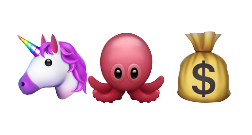

In [5]:
# --- Emoji rendering via Pillow (supports color glyphs; matplotlib text does not) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

SYMBOLS = {
    "agent": "\U0001F984",   # 🦄 unicorn
    "pit":   "\U0001F419",   # 🐙 octopus
    "goal":  "\U0001F4B0",   # 💰 money bag
}

# fallback plain-shape style, used if no emoji font is available at all
FALLBACK_STYLE = {
    "agent": dict(marker="*", color="#a855f7", markersize=26),   # purple star
    "pit":   dict(marker="o", color="#1e293b", markersize=20),   # dark circle
    "goal":  dict(marker="o", color="#eab308", markersize=22),   # gold circle
}

USE_EMOJI = _EMOJI_FONT_PATH is not None
_emoji_image_cache = {}
_emoji_font = None

if USE_EMOJI:
    from PIL import Image, ImageDraw, ImageFont

    # Color emoji fonts are usually bitmap-only and embed just one or two fixed pixel
    # sizes (e.g. Noto Color Emoji only has a 109px strike) -- asking for an arbitrary
    # size raises "OSError: invalid pixel size". Probe a range of common sizes instead
    # of hardcoding one, so this works across Noto, Apple Color Emoji, and Segoe UI Emoji.
    for _sz in (109, 128, 136, 160, 96, 64, 48, 32):
        try:
            _emoji_font = ImageFont.truetype(_EMOJI_FONT_PATH, _sz)
            EMOJI_RENDER_SIZE = _sz
            break
        except OSError:
            continue

    if _emoji_font is None:
        print("Could not find a usable bitmap size in this font — using shape fallback")
        USE_EMOJI = False

if USE_EMOJI:
    def render_emoji_image(emoji_char):
        """Render one emoji character to a small RGBA image, cached by character."""
        if emoji_char in _emoji_image_cache:
            return _emoji_image_cache[emoji_char]
        img = Image.new("RGBA", (EMOJI_RENDER_SIZE, EMOJI_RENDER_SIZE), (255, 255, 255, 0))
        draw = ImageDraw.Draw(img)
        try:
            draw.text((0, 0), emoji_char, font=_emoji_font, embedded_color=True)
        except TypeError:
            # older Pillow without embedded_color support: falls back to a plain glyph outline
            draw.text((0, 0), emoji_char, font=_emoji_font, fill=(0, 0, 0, 255))
        _emoji_image_cache[emoji_char] = img
        return img


    def place_emoji(ax, x, y, emoji_char, zoom=0.30, zorder=3):
        oi = OffsetImage(np.asarray(render_emoji_image(emoji_char)), zoom=zoom)
        ax.add_artist(AnnotationBbox(oi, (x, y), frameon=False, pad=0, zorder=zorder))

# --- smoke test: run this and check the three symbols actually look like
#     a unicorn, octopus and money bag (not blank space or boxes) ---
fig, ax = plt.subplots(figsize=(3, 1.5))
if USE_EMOJI:
    for i, sym in enumerate(SYMBOLS.values()):
        place_emoji(ax, i, 0, sym, zoom=0.35)
    ax.set_xlim(-0.5, len(SYMBOLS) - 0.5)
    ax.set_ylim(-0.5, 0.5)
else:
    ax.text(0.5, 0.5, "(emoji unavailable - using shape fallback below)", ha="center", va="center", fontsize=8)
ax.axis("off")
plt.show()


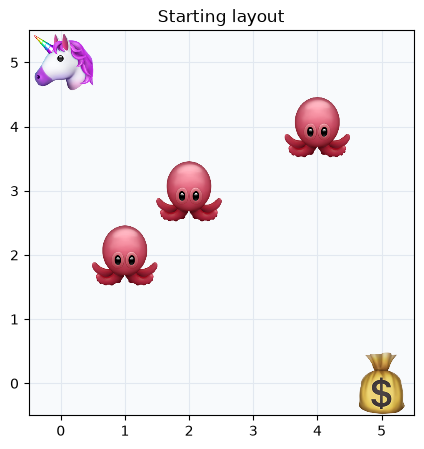

In [6]:
# --- Rendering helpers ---

def draw_cell(ax, row, col, kind, grid_size):
    """Draw one emoji (or fallback shape) at grid position (row, col)."""
    x, y = col, grid_size - 1 - row   # flip rows so the grid reads top-to-bottom
    if USE_EMOJI:
        place_emoji(ax, x, y, SYMBOLS[kind])
    else:
        style = FALLBACK_STYLE[kind]
        ax.plot(x, y, marker=style["marker"], color=style["color"], markersize=style["markersize"], zorder=3)


def render_grid(ax, env, agent_pos=None, path=None, title=None):
    """Draw the grid: octopus pits, the coin goal, an optional agent, and an optional trail."""
    ax.clear()
    size = env.size
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])
    ax.grid(True, color="#e2e8f0")
    ax.set_facecolor("#f8fafc")
    ax.set_aspect("equal")

    if path:   # faded trail of where the agent has already been
        for (r, c) in path[:-1]:
            x, y = c, size - 1 - r
            ax.plot(x, y, marker="o", color="#c4b5fd", markersize=16, alpha=0.5, zorder=1)

    for (r, c) in env.pits:
        draw_cell(ax, r, c, "pit", size)

    draw_cell(ax, *env.goal, "goal", size)

    if agent_pos is not None:
        draw_cell(ax, *agent_pos, "agent", size)

    if title:
        ax.set_title(title)


def render_policy(ax, env, q_table, title=None):
    """Draw the grid plus an arrow in every free cell showing the greedy action."""
    render_grid(ax, env, agent_pos=None, title=title)
    size = env.size
    arrow_offsets = {0: (0, 0.32), 1: (0, -0.32), 2: (-0.32, 0), 3: (0.32, 0)}  # up/down/left/right
    for r in range(size):
        for c in range(size):
            if (r, c) == env.goal or (r, c) in env.pits:
                continue
            best_a = int(np.argmax(q_table[r, c]))
            dx, dy = arrow_offsets[best_a]
            x, y = c, size - 1 - r
            ax.annotate("", xy=(x + dx, y + dy), xytext=(x, y),
                        arrowprops=dict(arrowstyle="->", color="#7c3aed", lw=2), zorder=2)


fig, ax = plt.subplots(figsize=(5, 5))
render_grid(ax, env, agent_pos=env.start, title="Starting layout")
plt.show()


In [7]:
# --- Q-learning training loop ---

n_actions = 4
grid_size = env.size
q_table = np.zeros((grid_size, grid_size, n_actions))

alpha = 0.5          # learning rate: how much each update shifts the estimate
gamma = 0.95         # discount factor: how much future reward matters
epsilon = 1.0        # exploration rate: start fully random
epsilon_decay = 0.99
epsilon_min = 0.05

n_episodes = 800
checkpoint_every = 40
max_steps_per_episode = 100

episode_rewards = []
snapshots = {}  # episode number -> copy of the Q-table, for showing policy evolution

for ep in range(1, n_episodes + 1):
    state = env.reset()
    total_reward = 0.0
    done = False
    steps = 0

    while not done and steps < max_steps_per_episode:
        r, c = state

        # epsilon-greedy: explore randomly, or exploit the current best-known action
        if random.random() < epsilon:
            action = random.randrange(n_actions)
        else:
            action = int(np.argmax(q_table[r, c]))

        next_state, reward, done = env.step(action)
        nr, nc = next_state

        # the Q-learning update rule
        best_next_value = np.max(q_table[nr, nc])
        td_target = reward + gamma * best_next_value
        q_table[r, c, action] += alpha * (td_target - q_table[r, c, action])

        state = next_state
        total_reward += reward
        steps += 1

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

    if ep == 1 or ep % checkpoint_every == 0:
        np.save(f"checkpoints/gridworld/qtable_ep{ep:04d}.npy", q_table)
        snapshots[ep] = q_table.copy()
        print(f"Episode {ep:4d} | reward {total_reward:6.2f} | epsilon {epsilon:.3f}")

print("\nTraining done. Checkpoints saved in checkpoints/gridworld/")


Episode    1 | reward -11.60 | epsilon 0.990
Episode   40 | reward -10.50 | epsilon 0.669
Episode   80 | reward -10.70 | epsilon 0.448
Episode  120 | reward -11.20 | epsilon 0.299
Episode  160 | reward -10.50 | epsilon 0.200
Episode  200 | reward   9.10 | epsilon 0.134
Episode  240 | reward   8.90 | epsilon 0.090
Episode  280 | reward   8.90 | epsilon 0.060
Episode  320 | reward   8.90 | epsilon 0.050
Episode  360 | reward   9.10 | epsilon 0.050
Episode  400 | reward   8.90 | epsilon 0.050
Episode  440 | reward   8.90 | epsilon 0.050
Episode  480 | reward   9.10 | epsilon 0.050
Episode  520 | reward   9.10 | epsilon 0.050
Episode  560 | reward   8.90 | epsilon 0.050
Episode  600 | reward   9.10 | epsilon 0.050
Episode  640 | reward   8.90 | epsilon 0.050
Episode  680 | reward   9.10 | epsilon 0.050
Episode  720 | reward   8.90 | epsilon 0.050
Episode  760 | reward   9.10 | epsilon 0.050
Episode  800 | reward   9.10 | epsilon 0.050

Training done. Checkpoints saved in checkpoints/gridwo

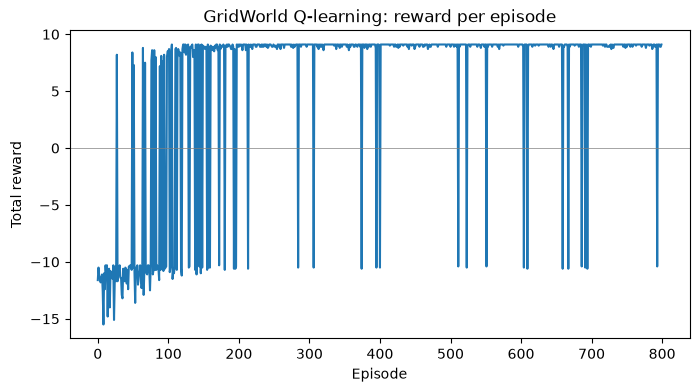

In [8]:
# --- Plot the learning curve ---

plt.figure(figsize=(8, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("GridWorld Q-learning: reward per episode")
plt.axhline(0, color="gray", linewidth=0.5)
plt.show()


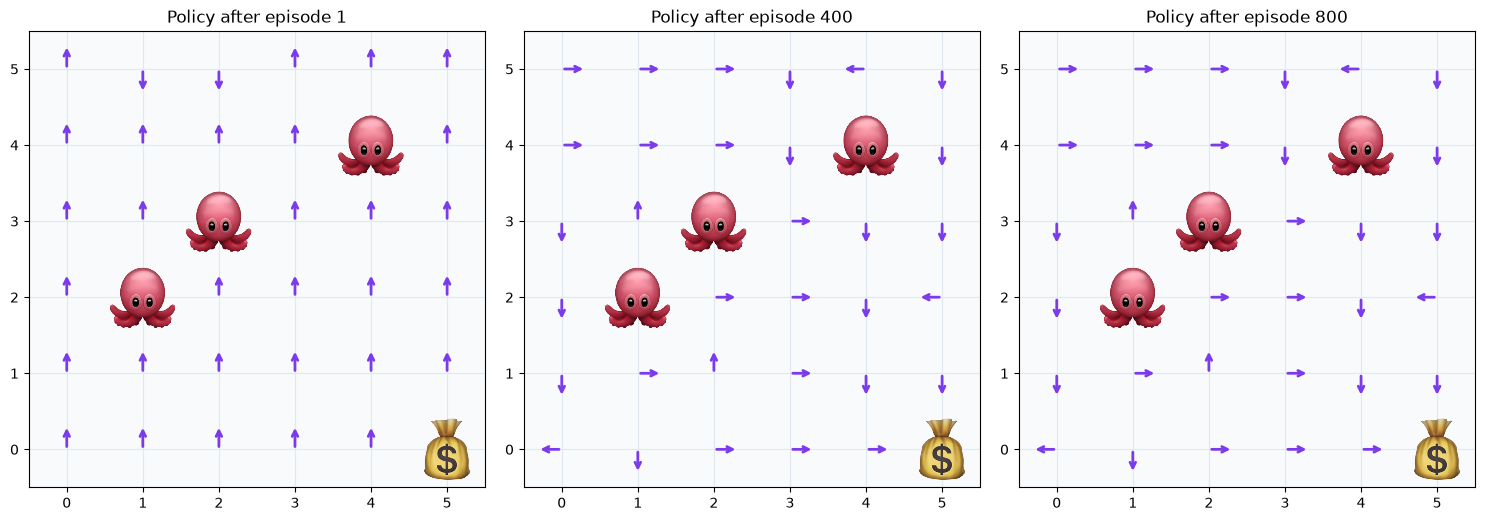

In [9]:
# --- Watch the policy improve: show it at the first, a middle, and the last checkpoint ---

ckpt_episodes = sorted(snapshots.keys())
to_show = [ckpt_episodes[0], ckpt_episodes[len(ckpt_episodes) // 2], ckpt_episodes[-1]]

fig, axes = plt.subplots(1, len(to_show), figsize=(5 * len(to_show), 5))
for ax, ep in zip(axes, to_show):
    render_policy(ax, env, snapshots[ep], title=f"Policy after episode {ep}")
plt.tight_layout()
plt.show()


### The learned value function: Q-value table

The arrows above come from picking, in each cell, the action with the highest
Q-value. Here's what's actually underneath them: a heatmap of the best (max) Q-value
per cell, plus the full numeric table for anyone who wants the exact numbers.


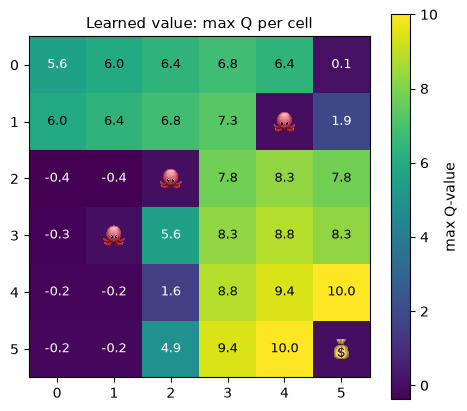

In [10]:
# --- Heatmap of the learned value function ---

max_q = q_table.max(axis=2).astype(float)   # best Q-value achievable from each cell

# Terminal cells (coin + octopus pits) are never updated as a *source* state, so their
# Q-value stays at 0.0 -- that doesn't mean "bad spot", it means "episode is over here".
terminal_cells = {env.goal: "goal", **{p: "pit" for p in env.pits}}

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#e2e8f0")   # light grey for masked terminal cells

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(max_q, cmap=cmap)
ax.set_title("Learned value: max Q per cell", fontsize=11)

vmin, vmax = np.nanmin(max_q), np.nanmax(max_q)
for r in range(grid_size):
    for c in range(grid_size):
        if (r, c) in terminal_cells:
            kind = terminal_cells[(r, c)]
            if USE_EMOJI:
                place_emoji(ax, c, r, SYMBOLS[kind], zoom=0.10)
            else:
                ax.text(c, r, "G" if kind == "goal" else "X", ha="center", va="center", fontsize=12)
            continue
        val = max_q[r, c]
        color = "white" if val < vmin + 0.6 * (vmax - vmin) else "black"
        ax.text(c, r, f"{val:.1f}", ha="center", va="center", color=color, fontsize=9)

plt.colorbar(im, ax=ax, label="max Q-value")
plt.show()


In [11]:
# --- Full numeric Q-table (every action-value, every cell) ---
import pandas as pd

rows = []
for r in range(grid_size):
    for c in range(grid_size):
        rows.append({
            "pos(r,c)": (r, c),
            "Q(up)": round(q_table[r, c, 0], 2),
            "Q(down)": round(q_table[r, c, 1], 2),
            "Q(left)": round(q_table[r, c, 2], 2),
            "Q(right)": round(q_table[r, c, 3], 2),
            "best_action": GridWorld.ACTIONS[int(np.argmax(q_table[r, c]))],
        })

q_table_df = pd.DataFrame(rows)
q_table_df[["pos(r,c)", "Q(up)", "Q(down)", "Q(left)", "Q(right)", "best_action"]]

,"pos(r,c)",Q(up),Q(down),Q(left),Q(right),best_action
0,"(0, 0)",5.18,5.56,5.18,5.56,right
1,"(0, 1)",5.56,5.96,5.18,5.96,right
2,"(0, 2)",5.96,6.38,5.56,6.38,right
3,"(0, 3)",6.37,6.82,5.96,5.96,down
4,"(0, 4)",1.96,-9.96,6.38,-0.36,left
5,"(0, 5)",-0.34,0.08,-0.33,-0.32,down
6,"(1, 0)",1.17,-0.44,-0.49,5.96,right
7,"(1, 1)",-0.42,-0.40,0.61,6.38,right
8,"(1, 2)",4.41,-10.00,4.40,6.82,right
9,"(1, 3)",6.38,7.29,6.37,-10.00,down


In [12]:
# --- Roll out the final, trained policy step by step (the "live demo" moment) ---

def rollout(env, q_table, max_steps=30, verbose=True):
    state = env.reset()
    path = [state]
    for t in range(max_steps):
        r, c = state
        action = int(np.argmax(q_table[r, c]))
        state, reward, done = env.step(action)
        path.append(state)
        if verbose:
            print(f"step {t+1:2d}: moved {GridWorld.ACTIONS[action]:>5s} -> {state}  (reward {reward:+.1f})")
        if done:
            print("Reached the coin!" if reward > 0 else "Fell in with the octopus.")
            break
    return path

final_path = rollout(env, q_table)


step  1: moved right -> (0, 1)  (reward -0.1)
step  2: moved right -> (0, 2)  (reward -0.1)
step  3: moved right -> (0, 3)  (reward -0.1)
step  4: moved  down -> (1, 3)  (reward -0.1)
step  5: moved  down -> (2, 3)  (reward -0.1)
step  6: moved right -> (2, 4)  (reward -0.1)
step  7: moved  down -> (3, 4)  (reward -0.1)
step  8: moved  down -> (4, 4)  (reward -0.1)
step  9: moved  down -> (5, 4)  (reward -0.1)
step 10: moved right -> (5, 5)  (reward +10.0)
Reached the coin!


In [13]:
# --- Animate the rollout: watch the unicorn walk the path live ---
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))

def update(frame):
    render_grid(ax, env, agent_pos=final_path[frame], path=final_path[: frame + 1],
                title=f"Step {frame} / {len(final_path) - 1}")

anim = FuncAnimation(fig, update, frames=len(final_path), interval=500, repeat=False)
plt.close(fig)
HTML(anim.to_jshtml())


## Part B — LunarLander with PPO (`stable-baselines3`)

Same core loop (agent, environment, reward, policy) — now on something visual.
We'll:
1. Record a **random** agent (fun to show — it flails).
2. **Train live** for a few minutes with checkpoints saved along the way.
3. Optionally load a **pretrained** checkpoint from the Hugging Face Hub for a
   guaranteed "solved" landing, in case live training doesn't converge in time.


In [14]:
!pip install -q "gymnasium[box2d]" stable-baselines3 huggingface_sb3 imageio imageio-ffmpeg


zsh:1: command not found: pip


In [15]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
import imageio
from IPython.display import Video

ENV_ID = "LunarLander-v3"

def record_video(model, filename, n_steps=700, random_policy=False, deterministic=True):
    """Roll out `model` (or a random policy) in the env and save an mp4."""
    env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = env.reset()
    frames = []
    for _ in range(n_steps):
        if random_policy:
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        if terminated or truncated:
            obs, info = env.reset()
    env.close()
    imageio.mimsave(filename, frames, fps=30, macro_block_size=1)
    return filename


print(f"Environment ready: {ENV_ID}")


Environment ready: LunarLander-v3


In [19]:
# --- 1. Random agent: watch it flail (no model needed) ---

random_video_path = record_video(
    model=None,
    filename="checkpoints/lunarlander/random_agent.mp4",
    random_policy=True,
    n_steps=500
)
Video(random_video_path, embed=True, width=480)


In [23]:
# --- 2. Train PPO live for a few minutes ---
# NOTE: LunarLander is usually considered "solved" around a mean reward of ~200,
# which typically takes ~500k-1M PPO steps. In a short live demo we won't fully solve
# it, but you SHOULD see the lander go from crashing hard to attempting controlled,
# slower descents. Be upfront about this trade-off with the audience -- it's part of
# the "RL takes real compute" lesson.

print("Running in Colab:", IN_COLAB)

TRAIN_LIVE = True
TIMESTEPS = 500_000          # lower = faster but less visible improvement
CHECKPOINT_EVERY = 50_000    # in per-env steps (see SB3 CheckpointCallback docs)
n_envs = 5                   # higher = faster training -> will run n_envs in parallel

vec_env = make_vec_env(ENV_ID, n_envs=n_envs)

checkpoint_callback = CheckpointCallback(
    save_freq=max(CHECKPOINT_EVERY // n_envs, 1),   # divide by n_envs, see SB3 docs
    save_path="checkpoints/lunarlander",
    name_prefix="ppo_lunarlander",
)

model = PPO (
        "MlpPolicy", 
        vec_env, 
        n_steps=1024,
        verbose=0 if IN_COLAB else 1
    )

if TRAIN_LIVE:
    model.learn(total_timesteps=TIMESTEPS, callback=checkpoint_callback, progress_bar=IN_COLAB)
    model.save("checkpoints/lunarlander/ppo_lunarlander_final")
    print("Training done, checkpoints in checkpoints/lunarlander/")


Running in Colab: False
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 87.1     |
|    ep_rew_mean     | -181     |
| time/              |          |
|    fps             | 9165     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 5120     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 91.4        |
|    ep_rew_mean          | -173        |
| time/                   |             |
|    fps                  | 5020        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.011874085 |
|    clip_fraction        | 0.0705      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.

In [25]:
# --- 3. Record the live-trained agent ---

trained_video_path = record_video(model, n_steps=500, filename="checkpoints/lunarlander/trained_agent.mp4")
Video(trained_video_path, embed=True, width=480)


### Recap

- **GridWorld**: showed the raw mechanics — a Q-table updating from trial and error,
  visible in seconds.
- **LunarLander**: same mechanics, now with a neural network policy (PPO) and a much
  richer environment — random flailing → visibly better control.
- All checkpoints are in `checkpoints/gridworld/` and `checkpoints/lunarlander/` if you
  want to reload and keep training.
